<div align="center">

# Universidad de Sevilla  
## Grado en Ingeniería del Software  
### Escuela Técnica Superior de Ingeniería Informática  
### Inteligencia Artificial (IA) – Curso 2025/2026  

<img src="../../img/portada.png" width="300"/>

---

#  Aprendizaje automático relacional  
### Primera Convocatoria – Junio 2026  

**Profesor:** Pedro Almagro Blanco

**Autores:**  
David Espina Apellaniz  
Marco Padilla Gómez  

**Fecha de entrega:** 8 de Junio de 2025  

</div>

# 02 - Extracción de features relacionales

En este notebook se transforma el grafo de Twitch en una tabla apta para entrenar modelos de Machine Learning.

El objetivo es generar el archivo:

`data/processed/twitch_mature_features.csv`

Este archivo será usado por todos los notebooks de modelos.


## 1. Importación de librerías y configuración inicial

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Permite importar módulos desde la carpeta src cuando el notebook está dentro de subcarpetas
sys.path.append("../../")

from src.data_loader import load_edges, load_target, load_json_features
from src.graph_features import build_graph, get_graph_summary, compute_graph_features
from src.preprocessing import (
    json_features_to_dataframe,
    build_final_dataset,
    save_processed_dataset
)
from src.visualization import save_correlation_matrix

DATA_RAW_PATH = Path("../../data/raw")
DATA_PROCESSED_PATH = Path("../../data/processed")
IMG_PATH = Path("../../img")

DATA_PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
IMG_PATH.mkdir(parents=True, exist_ok=True)


## 2. Carga de los datos originales

In [2]:
edges = load_edges(DATA_RAW_PATH / "ES_edges.csv")
target = load_target(DATA_RAW_PATH / "ES_target.csv")
features_json = load_json_features(DATA_RAW_PATH / "ES_features.json")

print("Edges shape:", edges.shape)
print("Target shape:", target.shape)
print("Número de nodos en JSON:", len(features_json))


Edges shape: (59382, 2)
Target shape: (4648, 6)
Número de nodos en JSON: 4648


## 3. Construcción del grafo

In [3]:
graph = build_graph(edges)
summary = get_graph_summary(graph)

summary

{'num_nodes': 4648,
 'num_edges': 59382,
 'density': 0.005498522726893927,
 'is_connected': True,
 'num_connected_components': 1,
 'largest_component_size': 4648}

## 4. Cálculo de métricas relacionales

Se calculan las principales métricas relacionales de cada nodo:

- `degree`
- `degree_centrality`
- `clustering`
- `pagerank`
- `closeness`
- `betweenness`
- `community`

La métrica `betweenness` se calcula de forma aproximada para reducir el tiempo de ejecución.


In [4]:
graph_features = compute_graph_features(
    graph,
    betweenness_k=500,
    random_state=42
)

graph_features.head()

,new_id,degree,degree_centrality,clustering,pagerank,closeness,betweenness,community
0,0,2,0.000430,1.000000,0.000047,0.344095,0.000000,0
1,1819,1022,0.219927,0.010956,0.008990,0.516850,0.107381,0
2,2840,22,0.004734,0.112554,0.000199,0.395691,0.000139,0
3,1,9,0.001937,0.111111,0.000145,0.348012,0.000266,13
4,1565,595,0.128040,0.032448,0.004585,0.489364,0.043826,1


In [5]:
graph_features.describe()

,new_id,degree,degree_centrality,clustering,pagerank,closeness,betweenness,community
count,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000
mean,2323.500000,25.551635,0.005499,0.222496,0.000215,0.352079,0.000408,1.172978
std,1341.906355,49.399858,0.010630,0.200727,0.000375,0.041139,0.002857,3.243139
min,0.000000,1.000000,0.000215,0.000000,0.000038,0.150808,0.000000,0.000000
25%,1161.750000,5.000000,0.001076,0.096552,0.000073,0.327744,0.000003,0.000000
50%,2323.500000,12.000000,0.002582,0.183532,0.000120,0.354828,0.000031,1.000000
75%,3485.250000,27.000000,0.005810,0.300000,0.000219,0.380099,0.000182,1.000000
max,4647.000000,1022.000000,0.219927,1.000000,0.008990,0.517483,0.107381,38.000000


## 5. Transformación del JSON en variable `num_features`

El archivo JSON contiene listas de características para cada usuario. Para este primer enfoque se crea una variable simple:

`num_features = número de características asociadas a cada usuario`


In [6]:
json_features_df = json_features_to_dataframe(features_json)
json_features_df.head()

,new_id,num_features
0,1412,16
1,3032,17
2,4032,16
3,3945,25
4,949,13


In [7]:
json_features_df["num_features"].describe()

count    4648.000000
mean       19.390921
std         6.053856
min         9.000000
25%        15.000000
50%        18.000000
75%        22.000000
max        77.000000
Name: num_features, dtype: float64

## 6. Unión de métricas relacionales, JSON y variable objetivo

Se construye el dataset final combinando:

- métricas relacionales del grafo;
- número de características del JSON;
- variables `days` y `views`;
- variable objetivo `mature`.


In [8]:
final_df = build_final_dataset(
    graph_features=graph_features,
    target=target,
    json_features=json_features_df
)

final_df.head()

,new_id,degree,degree_centrality,clustering,pagerank,closeness,betweenness,community,num_features,days,views,mature
0,0,2,0.000430,1.000000,0.000047,0.344095,0.000000,0,19,1347,1925,False
1,1819,1022,0.219927,0.010956,0.008990,0.516850,0.107381,0,13,2221,18196139,False
2,2840,22,0.004734,0.112554,0.000199,0.395691,0.000139,0,29,2138,3555,False
3,1,9,0.001937,0.111111,0.000145,0.348012,0.000266,13,23,1637,2350,False
4,1565,595,0.128040,0.032448,0.004585,0.489364,0.043826,1,40,1877,9362112,False


In [9]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4648 entries, 0 to 4647
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   new_id             4648 non-null   int64  
 1   degree             4648 non-null   int64  
 2   degree_centrality  4648 non-null   float64
 3   clustering         4648 non-null   float64
 4   pagerank           4648 non-null   float64
 5   closeness          4648 non-null   float64
 6   betweenness        4648 non-null   float64
 7   community          4648 non-null   int64  
 8   num_features       4648 non-null   int64  
 9   days               4648 non-null   int64  
 10  views              4648 non-null   int64  
 11  mature             4648 non-null   bool   
dtypes: bool(1), float64(5), int64(6)
memory usage: 404.1 KB


In [10]:
final_df["mature"].value_counts()

mature
False    3288
True     1360
Name: count, dtype: int64

## 7. Comprobación de valores nulos

In [11]:
final_df.isnull().sum()

new_id               0
degree               0
degree_centrality    0
clustering           0
pagerank             0
closeness            0
betweenness          0
community            0
num_features         0
days                 0
views                0
mature               0
dtype: int64

## 8. Matriz de correlación

Se genera una matriz de correlación para analizar la relación entre las variables numéricas y detectar posibles relaciones entre métricas.


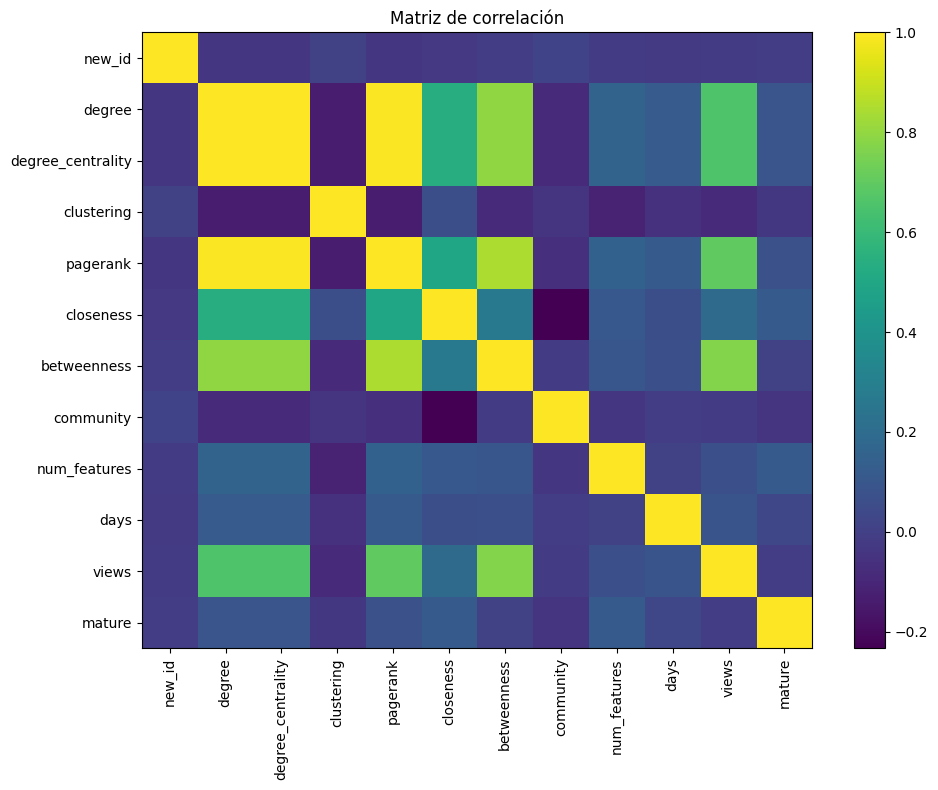

In [12]:
save_correlation_matrix(
    final_df,
    IMG_PATH / "matriz_correlacion.png"
)

# Mostrar también en el notebook
corr = final_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


## 9. Guardado del dataset procesado

Este CSV será el punto de partida para todos los modelos:

- Decision Tree
- Random Forest
- kNN


In [13]:
output_path = DATA_PROCESSED_PATH / "twitch_mature_features.csv"

save_processed_dataset(final_df, output_path)

print(f"Dataset procesado guardado en: {output_path}")


Dataset procesado guardado en: ..\..\data\processed\twitch_mature_features.csv


## 10. Comprobación final

Se carga de nuevo el CSV generado para comprobar que se ha guardado correctamente.


In [14]:
processed_df = pd.read_csv(DATA_PROCESSED_PATH / "twitch_mature_features.csv")

processed_df.head()

,new_id,degree,degree_centrality,clustering,pagerank,closeness,betweenness,community,num_features,days,views,mature
0,0,2,0.000430,1.000000,0.000047,0.344095,0.000000,0,19,1347,1925,False
1,1819,1022,0.219927,0.010956,0.008990,0.516850,0.107381,0,13,2221,18196139,False
2,2840,22,0.004734,0.112554,0.000199,0.395691,0.000139,0,29,2138,3555,False
3,1,9,0.001937,0.111111,0.000145,0.348012,0.000266,13,23,1637,2350,False
4,1565,595,0.128040,0.032448,0.004585,0.489364,0.043826,1,40,1877,9362112,False


In [15]:
processed_df.shape

(4648, 12)

## 11. Conclusiones

Conclusiones que se pueden usar en la memoria:

- Se ha generado una tabla final con una fila por usuario/nodo.
- Cada nodo queda representado mediante métricas relacionales calculadas a partir del grafo.
- La variable objetivo es `mature`.
- El archivo `twitch_mature_features.csv` permite entrenar modelos clásicos de Machine Learning para resolver una tarea de clasificación relacional de nodos.
